In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Lets load the boston house Pricing Dataset

In [11]:
from sklearn.datasets import fetch_california_housing

In [12]:
house=fetch_california_housing()

In [13]:
type(house)

sklearn.utils._bunch.Bunch

In [14]:
house.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [15]:
print(house.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

##preparing a Dataset

##prepare a Dataset

In [18]:
dataset=pd.DataFrame(house.data,columns=house.feature_names)

##to add feature heading we use above



In [19]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [20]:
dataset['Price']=house.target

In [21]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [23]:
##Summarize the stats of the data
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [24]:
## Missing values
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [25]:
## EDA
##CORRELATION  - checking how the independent features correlated to dependent feature

dataset.corr()

# If 2 independent feature highly correleated remove 1 --MULTICORRELATE
#neg correleation ---(inversely proportonal to each othe)
# posi corr -- directly proportional
# o corr -- No correlation
#


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


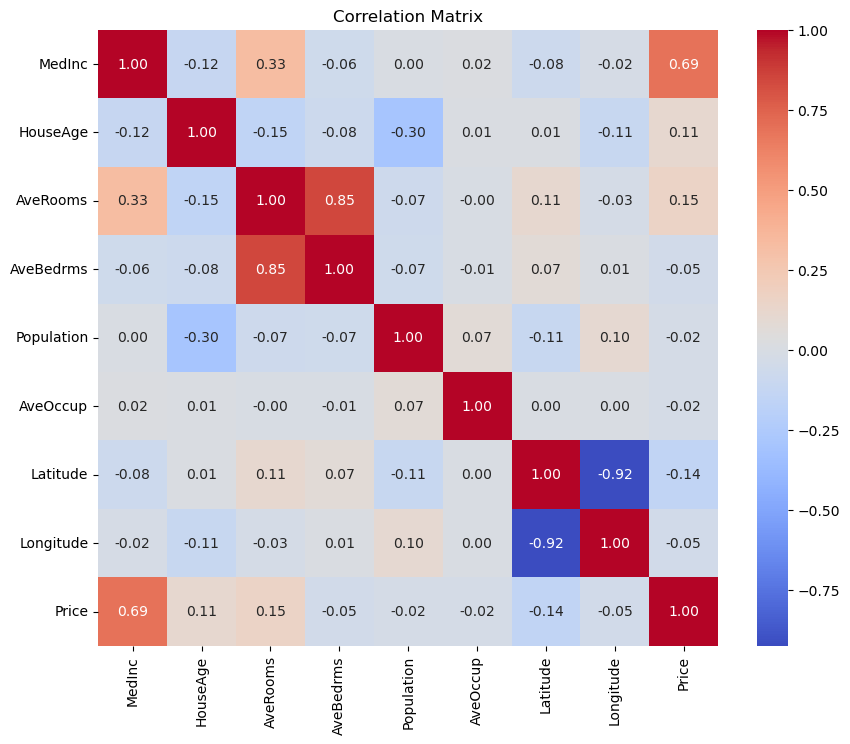

In [26]:
import seaborn as sns
cor=dataset.corr()
plt.figure(figsize=(10,8))
sns.heatmap(cor,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

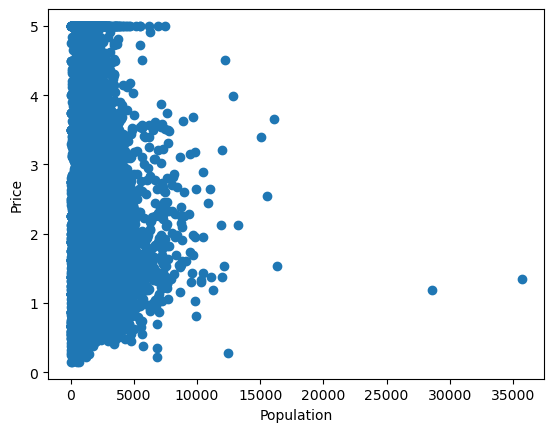

In [27]:

#negative correlation 

plt.scatter(dataset['Population'],dataset['Price'])
plt.xlabel('Population')
plt.ylabel('Price')
plt.show()

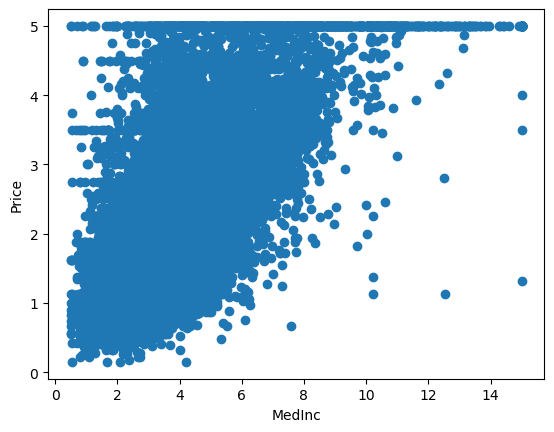

In [28]:
#positive correlation  

plt.scatter(dataset['MedInc'],dataset['Price'])
plt.xlabel('MedInc')
plt.ylabel('Price')
plt.show()


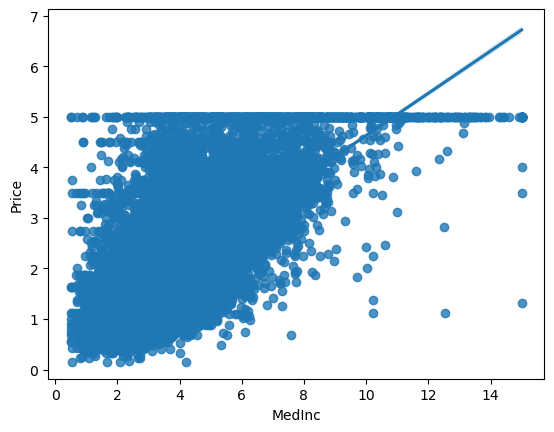

In [29]:
##positive correlation using reg plot
sns.regplot(x="MedInc" , y='Price',data=dataset)
plt.show()

In [30]:
## split dependent and independent features
X=dataset.iloc[:,:-1]  # inde
Y=dataset.iloc[:,-1] #dept

In [31]:
## Trainning and Testing
from sklearn.model_selection import train_test_split as tt
X_train,X_test,Y_train,Y_test=tt(X,Y,test_size=0.3,random_state=42)

#Each time you run the code, train_test_split() could shuffle the data differently, giving different results.


In [32]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [33]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
17505,2.9545,47.0,4.195833,1.020833,581.0,2.420833,37.36,-121.90
13512,1.4891,41.0,4.551852,1.118519,994.0,3.681481,34.11,-117.32
10842,3.5120,16.0,3.762287,1.075614,5014.0,2.369565,33.67,-117.91
16559,3.6500,10.0,5.502092,1.060371,5935.0,3.547519,37.82,-121.28


In [34]:
# Standrazing the dataset -- bz to converge it to global minima we want to have it and so GB occurs fast

# it'll convert all inde to same scale and so it;s fast to global minima

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)

#fit_transform --- It calculates the statistics (like mean and standard deviation for StandardScaler) AND applies the transformation.
# but we don't want to repeat the same fit so transform itself enough
X_test=scaler.transform(X_test)  # 

##Model Training

In [36]:
from sklearn.linear_model import LinearRegression

reg= LinearRegression()
reg.fit(X_train,Y_train)

LinearRegression()

In [37]:
#print the coefficient and the intercept  % for regression

print(reg.coef_) #similar to corr


[ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


In [38]:
print(reg.intercept_)

2.0692396089424165


In [39]:
## on which parameter the model hastrained

reg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [40]:
# Prediction with test data

r_pred=reg.predict(X_test)


In [41]:
r_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

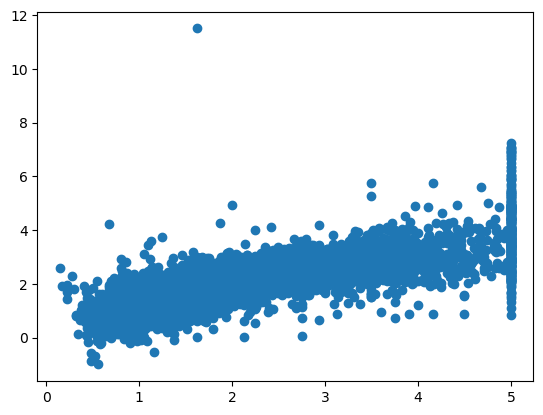

In [42]:
#plot a scatter plot for prediction

plt.scatter(Y_test,r_pred)
plt.show()

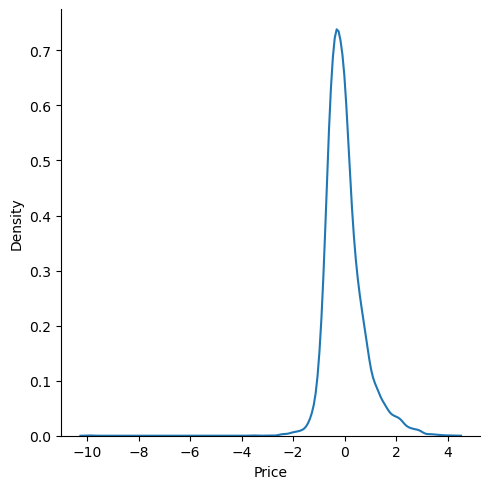

In [43]:
# prediction with residuals --error

residual=Y_test-r_pred

sns.displot(residual,kind='kde')
plt.show()

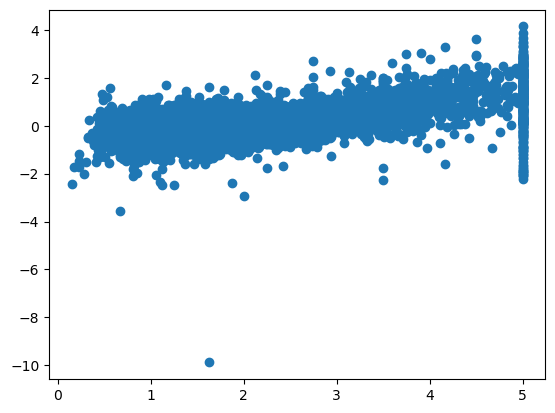

In [44]:
# scatter plot with respect to pred and resi
#uniform distribution

plt.scatter(Y_test,residual)
plt.show()

In [81]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(Y_test,r_pred))
print(mean_squared_error(Y_test,r_pred))
print(np.sqrt(mean_squared_error(Y_test,r_pred)))

0.5272474538305952
0.5305677824766754
0.7284008391515453


In [83]:
#R2 and adjusted r2

from sklearn.metrics import r2_score
score=r2_score(Y_test,r_pred)
print(score)


0.5957702326061662


In [89]:

l= 1- (1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)
print(l)

0.5952472117200025


#New Data Prediction

In [114]:
#to try to prediction we want the dataset in 2D so reshape(1,-1)  


sp=house.data[0].reshape(1,-1)

In [120]:
scaler.fit_transform(sp)

array([[0., 0., 0., 0., 0., 0., 0., 0.]])

In [131]:
reg.predict(scaler.fit_transform(sp))

array([2.06923961])

picklind -- Deployment

In [125]:
#by using we can deploy any platform and to predict any new dataset we can just load it

import pickle
pickle.dump(reg,open('regmodel.pkl','wb'))

In [127]:
pm=pickle.load(open('regmodel.pkl','rb'))

In [129]:
pm.predict(scaler.fit_transform(sp))

array([2.06923961])

In [1]:
import os
os.getcwd()


'C:\\Users\\Dharshini'